#PINNs for Data-Driven Identification
Our goal is to use PINNs to identify the axial rigidity $EA(x)$ of a static bar based on observed displacement $u(x)$, which is governed by
\begin{align}
\frac{\rm d}{{\rm d} x}\left( EA \frac{{\rm d} u}{{\rm d}x}  \right) + p=0,\ x\in\Omega.
\end{align}
Considering the domain to be $\Omega = [0,1]$, we assume $$EA(x) = x^3 - x^2 +1$$ and follow the manufactured solution $$u(x) = \sin(2\pi x),$$ which implies the distributed load $$p(x) = -2(3x^2-2x)\pi \cos(2\pi x) + 4(x^3 - x^2 + 1)\pi^2 \sin(2\pi x)$$ and the boundary conditions $$u(0)=u(1)=0.$$ We should note the these boundary conditions will not be considered in the training as they do not impact the unknown axial rigidity.

Install equinox:

In [ ]:
!pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.4 MB/s eta 0:00:00


Imports:

In [ ]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot  as plt

Exact solution, which is assumed to be given a priori:

In [ ]:
def exact_solution(x):
  return jnp.sin(2*jnp.pi*x)

##PINN
We define an MLP to approximate $EA(x)$:

In [ ]:
key = jax.random.PRNGKey(0)
key, init_key = jax.random.split(key)

pinn = eqx.nn.MLP(
    in_size='scalar',
    out_size='scalar',
    width_size=10,
    depth=2,
    activation=jax.nn.tanh,
    key=init_key
)

In [ ]:
def distributed_load(x):
  p = -2*(3*x**2 - 2*x)*jnp.pi*jnp.cos(2*jnp.pi*x) + \
      4*(x**3 - x**2 + 1) * jnp.pi**2 * jnp.sin(2*jnp.pi*x)
  return p

In [ ]:
def model_residual(network, x):
  r = jax.grad(network)(x) * jax.grad(exact_solution)(x) + \
      network(x) * jax.grad(jax.grad(exact_solution))(x) + distributed_load(x)
  return r

In [ ]:
model_residual(pinn, 0.1)

Array(20.666908, dtype=float32)

Collocation points:

In [ ]:
key, collocation_key = jax.random.split(key)
N_collocation = 30
x_collocation = jax.random.uniform(collocation_key, (N_collocation,), minval=0.0, maxval=1.0)

In [ ]:
def model_loss(network):
  r = jax.vmap(model_residual, in_axes=(None,0))(network, x_collocation)
  return 0.5 * jnp.mean(r**2)

In [ ]:
model_loss(pinn)

Array(259.43085, dtype=float32)

Optimizer:

In [ ]:
l_rate = 1e-02

optimizer = optax.adam(learning_rate=l_rate)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))

In [ ]:
@eqx.filter_jit
def make_step(network, state):
  loss, grad = eqx.filter_value_and_grad(model_loss)(network)
  updates, new_state = optimizer.update(grad, state)
  new_network = eqx.apply_updates(network, updates)
  return new_network, new_state, loss

In [ ]:
N_epochs = 10_000
loss_history = []

for epoch in range(N_epochs):
  pinn, opt_state, loss = make_step(pinn, opt_state)
  loss_history.append(loss)

  if epoch % 1000 == 0:
    print(f"Epoch: {epoch}, Loss: {loss}")

Epoch: 0, Loss: 259.43084716796875
Epoch: 1000, Loss: 0.45511263608932495
Epoch: 2000, Loss: 0.010876155458390713
Epoch: 3000, Loss: 0.00529078021645546
Epoch: 4000, Loss: 0.00398283451795578
Epoch: 5000, Loss: 0.07914409041404724
Epoch: 6000, Loss: 0.0077030896209180355
Epoch: 7000, Loss: 0.00209554354660213
Epoch: 8000, Loss: 0.001256650546565652
Epoch: 9000, Loss: 0.00045811524614691734


Text(0, 0.5, 'Loss')

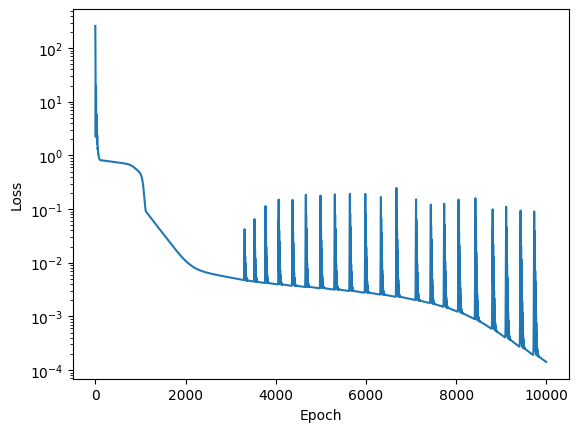

In [ ]:
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')

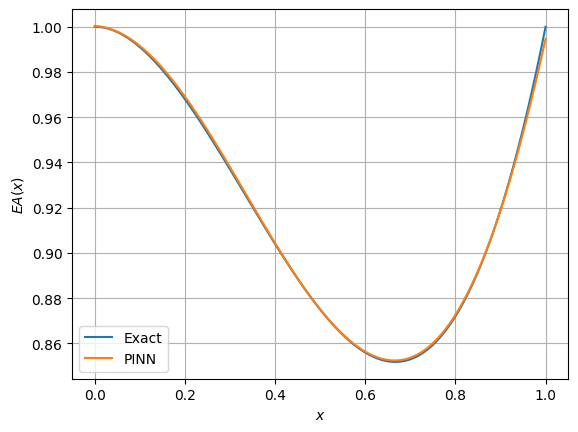

In [ ]:
x_grid = jnp.linspace(0.0, 1.0, 100)
EA_exact = x_grid**3 - x_grid**2 + 1
EA_pinn = jax.vmap(pinn)(x_grid)

plt.plot(x_grid, EA_exact, label='Exact')
plt.plot(x_grid, EA_pinn, label='PINN')
plt.xlabel(r'$x$')
plt.ylabel(r'$EA(x)$')
plt.legend()
plt.grid()
plt.show()